In [71]:
import torch
t_version = str(torch.__version__)
s_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
sp_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
!pip install torch-scatter -f $s_src
!pip install torch-sparse -f $sp_src
!pip install torch-geometric
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-9epbuqar'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [72]:
import torch_geometric
torch_geometric.__version__

'2.6.1'

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_scatter
from torch_scatter import scatter
from torch_geometric.nn import MessagePassing
from tqdm import trange
from torch_geometric.utils import degree
from torch_geometric.utils import add_self_loops, softmax
from sklearn.metrics import roc_auc_score, average_precision_score

# Define Graph Neural Network Stack

class GraphNNStack(nn.Module):
    def __init__(self, input_features, hidden_features, output_features, configuration, return_embeddings=True):
        super(GraphNNStack, self).__init__()

        assert configuration.model_type == 'GINConv'

        self.num_layers = min(configuration.num_layers, 5)
        self.dropout = configuration.dropout
        self.return_embeddings = return_embeddings

        self.convs = nn.ModuleList()

        # First layer
        self.convs.append(GINConv(input_features, hidden_features))

        # Hidden layers
        for _ in range(self.num_layers - 1):
            self.convs.append(GINConv(hidden_features, hidden_features))

        # Improved decoder
        self.decoder = EdgeDecoder(hidden_features)
        
    def select_conv_layer(self, conv_type):
        if conv_type == 'GINConv':
            return GINConv
        else:
            raise ValueError(f"Unknown model type: {conv_type}")       

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)

            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)

        return x

    def decode(self, z, edge_label_index):
        return self.decoder(z, edge_label_index)       
              

In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_scatter import scatter
from torch_geometric.utils import add_self_loops, degree
from torch.nn import Parameter


class GINConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super(GINConv, self).__init__(aggr='add')

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )

        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        out = self.propagate(edge_index, x=x)

        out = (1 + self.eps) * x + out

        return self.mlp(out)

    def message(self, x_j):
        return x_j
    
class EdgeDecoder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z, edge_index):
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]

        edge_feat = torch.cat([z_i, z_j], dim=-1)

        return self.mlp(edge_feat).view(-1)

In [75]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)

    return None, optimizer

In [76]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from torch_geometric.data import HeteroData, Data
import requests
import zipfile
import io
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score


def download_and_extract_lastfm():
    """Download LastFM dataset and extract it"""
    print("Downloading LastFM dataset...")
    
    url = "http://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"
    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"Failed to download dataset: HTTP {response.status_code}")

    # Create extraction directory
    extract_path = 'lastfm'
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset downloaded and extracted successfully!")
    
    # Check the actual extracted folder structure
    extracted_folder = os.path.join(extract_path, 'hetrec2011-lastfm-2k')
    if os.path.exists(extracted_folder):
        print(f"Files extracted to: {extracted_folder}")
        return extracted_folder
    else:
        # If the folder structure is different, list contents
        print("Contents of extraction directory:")
        for root, dirs, files in os.walk(extract_path):
            level = root.replace(extract_path, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f"{indent}{os.path.basename(root)}/")
            subindent = ' ' * 2 * (level + 1)
            for file in files[:5]:  # Show first 5 files
                print(f"{subindent}{file}")
        return extract_path


def load_lastfm_heterogeneous(data_path, embedding_dim=128):
    """Load Last.fm dataset and create HeteroData object with learnable embeddings"""
    print(f"Loading Last.fm dataset from: {data_path}")
    
    # List available files for debugging
    print("\nAvailable files in directory:")
    try:
        files = os.listdir(data_path)
        for f in files:
            print(f"  - {f}")
    except:
        print(f"  Could not list directory contents")
    
    # Read the data files with error handling
    try:
        artists_df = pd.read_csv(os.path.join(data_path, 'artists.dat'), 
                               sep='\t', encoding='latin-1')
        print(f"✓ Loaded artists.dat: {len(artists_df)} records")
    except FileNotFoundError:
        print(f"✗ artists.dat not found at {os.path.join(data_path, 'artists.dat')}")
        raise
    
    try:
        user_artists_df = pd.read_csv(os.path.join(data_path, 'user_artists.dat'), 
                                    sep='\t')
        print(f"✓ Loaded user_artists.dat: {len(user_artists_df)} records")
    except FileNotFoundError:
        print(f"✗ user_artists.dat not found")
        raise
    
    try:
        user_friends_df = pd.read_csv(os.path.join(data_path, 'user_friends.dat'), 
                                    sep='\t')
        print(f"✓ Loaded user_friends.dat: {len(user_friends_df)} records")
    except FileNotFoundError:
        print(f"✗ user_friends.dat not found")
        raise
    
    try:
        # Try to load either timestamp or regular version
        timestamp_file = os.path.join(data_path, 'user_taggedartists-timestamps.dat')
        regular_file = os.path.join(data_path, 'user_taggedartists.dat')
        
        if os.path.exists(timestamp_file):
            user_taggedartists_df = pd.read_csv(timestamp_file, sep='\t')
            print(f"✓ Loaded user_taggedartists-timestamps.dat: {len(user_taggedartists_df)} records")
        elif os.path.exists(regular_file):
            user_taggedartists_df = pd.read_csv(regular_file, sep='\t')
            print(f"✓ Loaded user_taggedartists.dat: {len(user_taggedartists_df)} records")
        else:
            raise FileNotFoundError("Neither user_taggedartists-timestamps.dat nor user_taggedartists.dat found")
    except FileNotFoundError:
        print(f"✗ Tagged artists file not found")
        raise
    
    try:
        tags_df = pd.read_csv(os.path.join(data_path, 'tags.dat'), 
                            sep='\t', encoding='latin-1')
        print(f"✓ Loaded tags.dat: {len(tags_df)} records")
    except FileNotFoundError:
        print(f"✗ tags.dat not found")
        raise
    
    # Create HeteroData object
    data = HeteroData()
    
    # 1. Get ALL unique users
    all_users = set(user_artists_df['userID']).union(
        user_friends_df['userID']).union(
        user_friends_df['friendID']).union(
        user_taggedartists_df['userID'])
    
    num_users = len(all_users)
    user_id_to_idx = {uid: idx for idx, uid in enumerate(sorted(all_users))}
    
    # 2. Get ALL unique artists
    all_artists = set(artists_df['id']).union(
        set(user_artists_df['artistID'])).union(
        set(user_taggedartists_df['artistID']))
    
    num_artists = len(all_artists)
    artist_id_to_idx = {aid: idx for idx, aid in enumerate(sorted(all_artists))}
    
    # 3. Get ALL unique tags
    all_tags = set(tags_df['tagID']).union(set(user_taggedartists_df['tagID']))
    
    num_tags = len(all_tags)
    tag_id_to_idx = {tid: idx for idx, tid in enumerate(sorted(all_tags))}
    
    print(f"\nStatistics - Users: {num_users}, Artists: {num_artists}, Tags: {num_tags}")
    
    # ============ MODIFIED: Use learnable embeddings instead of identity features ============
    
    print(f"\nUsing learnable embeddings with dimension: {embedding_dim}")
    
    # Create learnable embeddings for each node type
    # These will be optimized during training
    user_embeddings = nn.Parameter(torch.randn(num_users, embedding_dim))
    artist_embeddings = nn.Parameter(torch.randn(num_artists, embedding_dim))
    tag_embeddings = nn.Parameter(torch.randn(num_tags, embedding_dim))
    
    # Initialize with Xavier uniform for better training
    nn.init.xavier_uniform_(user_embeddings)
    nn.init.xavier_uniform_(artist_embeddings)
    nn.init.xavier_uniform_(tag_embeddings)
    
    # Normalize embeddings for better training stability
    user_embeddings = nn.Parameter(F.normalize(user_embeddings, p=2, dim=1))
    artist_embeddings = nn.Parameter(F.normalize(artist_embeddings, p=2, dim=1))
    tag_embeddings = nn.Parameter(F.normalize(tag_embeddings, p=2, dim=1))
    
    # Store as node features
    data['user'].x = user_embeddings
    data['artist'].x = artist_embeddings
    data['tag'].x = tag_embeddings
    
    # Store node counts
    data['user'].num_nodes = num_users
    data['artist'].num_nodes = num_artists
    data['tag'].num_nodes = num_tags
    
    # ============ Rest of the code remains the same ============
    
    # 4. User-listens-artist edges
    edge_index_listens = []
    edge_attr_listens = []
    valid_listens = 0
    skipped_listens = 0
    
    for _, row in user_artists_df.iterrows():
        user_id = row['userID']
        artist_id = row['artistID']
        
        if user_id in user_id_to_idx and artist_id in artist_id_to_idx:
            user_idx = user_id_to_idx[user_id]
            artist_idx = artist_id_to_idx[artist_id]
            edge_index_listens.append([user_idx, artist_idx])
            edge_attr_listens.append(float(row['weight']))
            valid_listens += 1
        else:
            skipped_listens += 1
    
    #print(f"User-listens-artist relations: {valid_listens} (skipped: {skipped_listens})")
    print(f"User-listens-artist relations: {valid_listens}")
    
    if edge_index_listens:
        data['user', 'listens', 'artist'].edge_index = torch.tensor(
            edge_index_listens, dtype=torch.long).t().contiguous()
        data['user', 'listens', 'artist'].weight = torch.tensor(
            edge_attr_listens, dtype=torch.float)
        
        # Store original user-artist edges for link prediction
        data['user', 'listens', 'artist'].original_edge_index = data['user', 'listens', 'artist'].edge_index.clone()
    
    # 5. User-tags-artist edges
    edge_index_user_tags_artist = []
    valid_tag_assignments = 0
    
    for _, row in user_taggedartists_df.iterrows():
        user_id = row['userID']
        artist_id = row['artistID']
        
        if (user_id in user_id_to_idx and artist_id in artist_id_to_idx):
            user_idx = user_id_to_idx[user_id]
            artist_idx = artist_id_to_idx[artist_id]
            edge_index_user_tags_artist.append([user_idx, artist_idx])
            valid_tag_assignments += 1
    
    print(f"User-tags-artist relations: {valid_tag_assignments}")
    
    if edge_index_user_tags_artist:
        data['user', 'tags', 'artist'].edge_index = torch.tensor(
            edge_index_user_tags_artist, dtype=torch.long).t().contiguous()
    
    # 6. Artist-tagged_with-tag edges
    edge_index_artist_tagged_with_tag = []
    artist_tag_pairs = set()
    
    for _, row in user_taggedartists_df.iterrows():
        artist_id = row['artistID']
        tag_id = row['tagID']
        
        if artist_id in artist_id_to_idx and tag_id in tag_id_to_idx:
            artist_idx = artist_id_to_idx[artist_id]
            tag_idx = tag_id_to_idx[tag_id]
            
            pair = (artist_idx, tag_idx)
            if pair not in artist_tag_pairs:
                artist_tag_pairs.add(pair)
                edge_index_artist_tagged_with_tag.append([artist_idx, tag_idx])
    
    print(f"Artist-tagged_with-tag relations (unique): {len(edge_index_artist_tagged_with_tag)}")
    
    if edge_index_artist_tagged_with_tag:
        data['artist', 'tagged_with', 'tag'].edge_index = torch.tensor(
            edge_index_artist_tagged_with_tag, dtype=torch.long).t().contiguous()
    
    # 7. User-friends-user edges (bidirectional)
    edge_index_friends = []
    friend_pairs = set()
    valid_friends = 0
    
    for _, row in user_friends_df.iterrows():
        user1_id = row['userID']
        user2_id = row['friendID']
        
        if user1_id in user_id_to_idx and user2_id in user_id_to_idx:
            user1_idx = user_id_to_idx[user1_id]
            user2_idx = user_id_to_idx[user2_id]
            
            friend_pair = tuple(sorted([user1_idx, user2_idx]))
            
            if friend_pair not in friend_pairs:
                friend_pairs.add(friend_pair)
                edge_index_friends.append([user1_idx, user2_idx])
                edge_index_friends.append([user2_idx, user1_idx])
                valid_friends += 2
    
    print(f"User-friends-user relations: {valid_friends}")
    
    if edge_index_friends:
        data['user', 'friends', 'user'].edge_index = torch.tensor(
            edge_index_friends, dtype=torch.long).t().contiguous()
    
    print(f"\nFINAL STATISTICS:")
    print(f"  Users: {data['user'].num_nodes}")
    print(f"  Artists: {data['artist'].num_nodes}")
    print(f"  Tags: {data['tag'].num_nodes}")
    print(f"  User→Artist (listens): {valid_listens}")
    print(f"  User→Artist (tags): {valid_tag_assignments}")
    print(f"  Artist→Tag: {len(edge_index_artist_tagged_with_tag)}")
    print(f"  User↔User (friends): {valid_friends}")
    print(f"  Embedding dimension: {embedding_dim}")
    
    return data

def convert_lastfm_to_homogeneous(data):
    """Convert Last.fm heterogeneous graph to homogeneous graph"""
    print("Converting to homogeneous graph...")

    num_users = data['user'].num_nodes
    num_artists = data['artist'].num_nodes
    num_tags = data['tag'].num_nodes
    total_nodes = num_users + num_artists + num_tags

    edge_indices = []

    # User-listens-artist edges (bidirectional)
    if ('user', 'listens', 'artist') in data.edge_types:
        user_listens_artist = data['user', 'listens', 'artist'].edge_index
        user_listens_artist_adj = user_listens_artist.clone()
        user_listens_artist_adj[1] += num_users
        
        artist_listens_user = torch.stack([user_listens_artist[1], user_listens_artist[0]], dim=0)
        artist_listens_user[0] += num_users
        artist_listens_user[1] += 0
        
        edge_indices.append(user_listens_artist_adj)
        edge_indices.append(artist_listens_user)

    # User-tags-artist edges (bidirectional)
    if ('user', 'tags', 'artist') in data.edge_types:
        user_tags_artist = data['user', 'tags', 'artist'].edge_index
        user_tags_artist_adj = user_tags_artist.clone()
        user_tags_artist_adj[1] += num_users
        
        artist_tags_user = torch.stack([user_tags_artist[1], user_tags_artist[0]], dim=0)
        artist_tags_user[0] += num_users
        artist_tags_user[1] += 0
        
        edge_indices.append(user_tags_artist_adj)
        edge_indices.append(artist_tags_user)

    # Artist-tagged_with-tag edges (bidirectional)
    if ('artist', 'tagged_with', 'tag') in data.edge_types:
        artist_tagged_with_tag = data['artist', 'tagged_with', 'tag'].edge_index
        artist_tagged_with_tag_adj = artist_tagged_with_tag.clone()
        artist_tagged_with_tag_adj[0] += num_users
        artist_tagged_with_tag_adj[1] += num_users + num_artists
        
        tag_tagged_with_artist = torch.stack([artist_tagged_with_tag[1], artist_tagged_with_tag[0]], dim=0)
        tag_tagged_with_artist[0] += num_users + num_artists
        tag_tagged_with_artist[1] += num_users
        
        edge_indices.append(artist_tagged_with_tag_adj)
        edge_indices.append(tag_tagged_with_artist)

    # User-friends-user edges
    if ('user', 'friends', 'user') in data.edge_types:
        user_friends_user = data['user', 'friends', 'user'].edge_index
        edge_indices.append(user_friends_user)

    if edge_indices:
        edge_index = torch.cat(edge_indices, dim=1)
        edge_index = torch.unique(edge_index, dim=1)
        print(f"Created {edge_index.shape[1]} edges in homogeneous graph")
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        print("Warning: No edges found in homogeneous graph!")

    # Combine node features
    user_features = data['user'].x.float()
    artist_features = data['artist'].x.float()
    tag_features = data['tag'].x.float()

    max_dim = max(user_features.shape[1], artist_features.shape[1], tag_features.shape[1])

    if user_features.shape[1] < max_dim:
        user_features = F.pad(user_features, (0, max_dim - user_features.shape[1]))
    if artist_features.shape[1] < max_dim:
        artist_features = F.pad(artist_features, (0, max_dim - artist_features.shape[1]))
    if tag_features.shape[1] < max_dim:
        tag_features = F.pad(tag_features, (0, max_dim - tag_features.shape[1]))

    x = torch.cat([user_features, artist_features, tag_features], dim=0)

    # Store original user-artist edges for link prediction
    original_edges = None
    if ('user', 'listens', 'artist') in data.edge_types:
        original_edges = data['user', 'listens', 'artist'].edge_index
        print(f"Stored original user-artist edges: {original_edges.shape[1]}")

    homogeneous_data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=total_nodes,
        num_users=num_users,
        num_artists=num_artists,
        num_tags=num_tags,
        original_user_artist_edges=original_edges
    )

    print(f"Homogeneous graph created with {homogeneous_data.num_nodes} nodes")
    return homogeneous_data


def print_dataset_details(homogeneous_data):
    """Print dataset details for LastFM"""
    print("\n" + "="*60)
    print(f"Dataset name: LastFM (hetrec2011-lastfm-2k)")
    print(f"Total nodes: {homogeneous_data.num_nodes}")
    print(f"Total edges: {homogeneous_data.edge_index.shape[1]}")
    print(f"Number of artist nodes: {homogeneous_data.num_artists}")
    print(f"Number of user nodes: {homogeneous_data.num_users}")
    print(f"Number of tag nodes: {homogeneous_data.num_tags}")
    print(f"Feature dimension: {homogeneous_data.x.shape[1]}")
    print("="*60)

    
    
def prepare_link_prediction_data(homogeneous_data):
    """Prepare homogeneous graph data for link prediction using real user-artist listening data"""
    print("\n" + "="*60)
    print("Preparing data for link prediction...")
    print("="*60)
    
    num_users = homogeneous_data.num_users
    num_artists = homogeneous_data.num_artists
    
    # Get original user-artist listening edges
    if homogeneous_data.original_user_artist_edges is None:
        print("ERROR: No original user-artist edges found!")
        return homogeneous_data
    
    # Adjust artist indices for homogeneous graph
    pos_edge_index = homogeneous_data.original_user_artist_edges.clone()
    pos_edge_index[1] += num_users
    
    print(f"Original user-artist listening edges: {pos_edge_index.shape[1]}")
    
    pos_edge_label = torch.ones(pos_edge_index.size(1), dtype=torch.float)
    
    # Generate negative samples (3x negatives)
    num_neg_samples = pos_edge_index.size(1) * 3
    neg_users = torch.randint(0, num_users, (num_neg_samples,))
    neg_artists = torch.randint(num_users, num_users + num_artists, (num_neg_samples,))
    neg_edge_index = torch.stack([neg_users, neg_artists])
    neg_edge_label = torch.zeros(neg_edge_index.size(1), dtype=torch.float)
    
    # Combine positive and negative
    all_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    all_edge_label = torch.cat([pos_edge_label, neg_edge_label])
    
    # Shuffle
    perm = torch.randperm(all_edge_index.size(1))
    all_edge_index = all_edge_index[:, perm]
    all_edge_label = all_edge_label[perm]
    
    # Split into train/val/test (70/15/15)
    num_edges = all_edge_index.size(1)
    train_size = int(0.7 * num_edges)
    val_size = int(0.15 * num_edges)
    
    train_edge_index = all_edge_index[:, :train_size]
    train_edge_label = all_edge_label[:train_size]
    
    val_edge_index = all_edge_index[:, train_size:train_size + val_size]
    val_edge_label = all_edge_label[train_size:train_size + val_size]
    
    test_edge_index = all_edge_index[:, train_size + val_size:]
    test_edge_label = all_edge_label[train_size + val_size:]
    
    homogeneous_data.train_pos_edge_index = train_edge_index[:, train_edge_label == 1]
    homogeneous_data.train_edge_index = train_edge_index
    homogeneous_data.train_edge_label = train_edge_label
    
    homogeneous_data.val_edge_index = val_edge_index
    homogeneous_data.val_edge_label = val_edge_label
    
    homogeneous_data.test_edge_index = test_edge_index
    homogeneous_data.test_edge_label = test_edge_label
    
    print(f"\nLink Prediction Data Statistics:")
    print(f"Total edges: {num_edges} ({pos_edge_index.shape[1]} positive, {neg_edge_index.shape[1]} negative)")
    print(f"Train edges: {train_edge_index.shape[1]} ({int(train_edge_label.sum())} positive)")
    print(f"Validation edges: {val_edge_index.shape[1]} ({int(val_edge_label.sum())} positive)")
    print(f"Test edges: {test_edge_index.shape[1]} ({int(test_edge_label.sum())} positive)")
    
    return homogeneous_data



# Train the Model
def train_link_prediction_model(data, configuration):
    """Train model for link prediction"""
    model = GraphNNStack(data.num_node_features, configuration.hidden_dim, 
                         configuration.hidden_dim, configuration, return_embeddings=True)
    optimizer = optim.Adam(model.parameters(), lr=configuration.learning_rate, 
                          weight_decay=configuration.weight_decay)
    
    losses = []
    val_aucs = []
    val_aps = []
    
    for epoch in trange(configuration.epochs, desc="Link Prediction Training"):
        model.train()
        optimizer.zero_grad()
        
        z = model(data)
        
        pos_edge_index = data.train_pos_edge_index
        
        if pos_edge_index.shape[1] == 0:
            print("Warning: No positive edges in training set!")
            break
        
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1)
        )
        
        pos_pred = model.decode(z, pos_edge_index)
        neg_pred = model.decode(z, neg_edge_index)
        
        pos_loss = -torch.log(torch.sigmoid(pos_pred) + 1e-15).mean()
        neg_loss = -torch.log(1 - torch.sigmoid(neg_pred) + 1e-15).mean()
        loss = pos_loss + neg_loss
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                z = model(data)
                
                val_pred = model.decode(z, data.val_edge_index)
                val_pred = torch.sigmoid(val_pred)
                
                val_auc = roc_auc_score(data.val_edge_label.cpu().numpy(), 
                                         val_pred.cpu().numpy())
                val_ap = average_precision_score(data.val_edge_label.cpu().numpy(), 
                                                  val_pred.cpu().numpy())
                
                val_aucs.append(val_auc)
                val_aps.append(val_ap)
    
    # Final test evaluation
    model.eval()
    with torch.no_grad():
        z = model(data)
        
        test_pred = model.decode(z, data.test_edge_index)
        test_pred_sigmoid = torch.sigmoid(test_pred)
        
        test_auc = roc_auc_score(data.test_edge_label.cpu().numpy(), 
                                   test_pred_sigmoid.cpu().numpy())
        test_ap = average_precision_score(data.test_edge_label.cpu().numpy(), 
                                           test_pred_sigmoid.cpu().numpy())
        
        test_pred_binary = (test_pred_sigmoid > 0.5).float()
        test_accuracy = (test_pred_binary == data.test_edge_label).float().mean().item()
        test_precision = precision_score(data.test_edge_label.cpu().numpy(), 
                                          test_pred_binary.cpu().numpy(), zero_division=0)
        test_recall = recall_score(data.test_edge_label.cpu().numpy(), 
                                    test_pred_binary.cpu().numpy(), zero_division=0)
        test_f1 = f1_score(data.test_edge_label.cpu().numpy(), 
                            test_pred_binary.cpu().numpy(), zero_division=0)
    
    test_metrics = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc,
        'ap': test_ap
    }
    
    return val_aucs, losses, model, test_metrics


def evaluate_recommendation(model, data, k_list=[5, 10, 20]):
    """Evaluate recommendation performance"""
    model.eval()
    
    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []
    
    with torch.no_grad():
        z = model(data)
        
        pos_edges = data.test_edge_index[:, data.test_edge_label == 1]
        
        if pos_edges.shape[1] == 0:
            print("Warning: No positive test edges for recommendation evaluation!")
            return {f'HR@{k}': 0 for k in k_list} | {f'NDCG@{k}': 0 for k in k_list} | {'MRR': 0}
        
        for edge in pos_edges.t():
            user = edge[0].item()
            pos_artist = edge[1].item()
            
            # Sample negative artists
            all_artists = set(range(data.num_users, data.num_users + data.num_artists))
            user_seen = set(data.train_pos_edge_index[1][data.train_pos_edge_index[0] == user].cpu().numpy())
            candidate_artists = list(all_artists - user_seen)
            
            if len(candidate_artists) < 99:
                continue
                
            neg_artists = np.random.choice(candidate_artists, 99, replace=False)
            candidates = list(neg_artists) + [pos_artist]
            
            users = torch.full((len(candidates),), user)
            artists = torch.tensor(candidates)
            edge_index = torch.stack([users, artists])
            
            scores = model.decode(z, edge_index).cpu().numpy()
            ranking = np.argsort(scores)[::-1]
            ranked_artists = [candidates[i] for i in ranking]
            
            for k in k_list:
                if pos_artist in ranked_artists[:k]:
                    HR[k].append(1)
                    rank = ranked_artists.index(pos_artist) + 1
                    NDCG[k].append(1 / np.log2(rank + 1))
                else:
                    HR[k].append(0)
                    NDCG[k].append(0)
            
            rank = ranked_artists.index(pos_artist) + 1
            MRR.append(1 / rank)
    
    results = {}
    for k in k_list:
        results[f'HR@{k}'] = np.mean(HR[k]) if HR[k] else 0
        results[f'NDCG@{k}'] = np.mean(NDCG[k]) if NDCG[k] else 0
    results['MRR'] = np.mean(MRR) if MRR else 0
    
    return results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)


STEP 1: Loading LastFM Dataset
Dataset downloaded and extracted successfully!
Contents of extraction directory:
lastfm/
  artists.dat
  readme.txt
  tags.dat
  user_artists.dat
  user_friends.dat
Loading Last.fm dataset from: lastfm

Available files in directory:
  - artists.dat
  - readme.txt
  - tags.dat
  - user_artists.dat
  - user_friends.dat
  - user_taggedartists-timestamps.dat
  - user_taggedartists.dat
✓ Loaded artists.dat: 17632 records
✓ Loaded user_artists.dat: 92834 records
✓ Loaded user_friends.dat: 25434 records
✓ Loaded user_taggedartists-timestamps.dat: 186479 records
✓ Loaded tags.dat: 11946 records

Statistics - Users: 1892, Artists: 18022, Tags: 11946

Using learnable embeddings with dimension: 128
User-listens-artist relations: 92834
User-tags-artist relations: 186479
Artist-tagged_with-tag relations (unique): 109750
User-friends-user relations: 25434

FINAL STATISTICS:
  Users: 1892
  Artists: 18022
  Tags: 11946
  User→Artist (listens): 92834
  User→Artist (tags

Link Prediction Training: 100%|██████████████████████████████████████████████████████| 200/200 [01:03<00:00,  3.15it/s]



FINAL RESULTS
Model: GINConv
Dataset: LastFM (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC:       0.8622
AP:        0.7286

--- RECOMMENDATION METRICS ---
HR@5:   0.5451
HR@10:  0.6592
HR@20:  0.7583
NDCG@5:  0.4091
NDCG@10: 0.4462
NDCG@20: 0.4713
MRR:     0.3920

Time Taken: 63.76 seconds


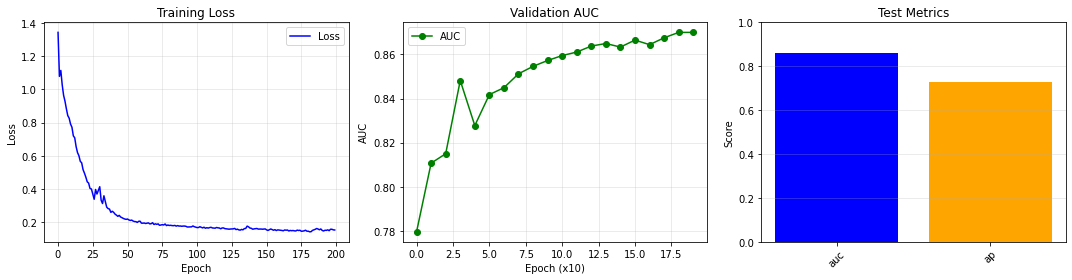

In [77]:
def main_link_prediction():
    configurations = [
        {
            'model_type': 'GINConv',
            'dataset': 'LastFM',
            'num_layers': 2,
            'heads': 1,
            'hidden_dim': 64,
            'embedding_dim': 128,  # Add this line
            'dropout': 0.3,
            'epochs': 200,
            'optimizer': 'adam',
            'weight_decay': 5e-4,
            'learning_rate': 0.003
        },
    ]

    for config_dict in configurations:
        config = Config(config_dict)
        
        # Set device
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        #print(f"Using device: {device}")

        # Load and prepare data with embedding dimension
        print("\n" + "="*60)
        print("STEP 1: Loading LastFM Dataset")
        print("="*60)
        data_path = download_and_extract_lastfm()
       
        heterogeneous_data = load_lastfm_heterogeneous(data_path, embedding_dim=config.embedding_dim)
        
               
        print("\n" + "="*60)
        print("STEP 2: Converting to Homogeneous Graph")
        print("="*60)
        homogeneous_data = convert_lastfm_to_homogeneous(heterogeneous_data)
        homogeneous_data = homogeneous_data.to(device)  # Move to device
        print_dataset_details(homogeneous_data)
        
        print("\n" + "="*60)
        print("STEP 3: Preparing Data for Link Prediction")
        print("="*60)
        homogeneous_data = prepare_link_prediction_data(homogeneous_data)

        print("\n" + "="*60)
        print(f"STEP 4: Training {config.model_type} for LINK PREDICTION")
        print("="*60)

        start_time = time.time()
        val_aucs, losses, best_model, test_metrics = train_link_prediction_model(homogeneous_data, config)
        end_time = time.time()
        elapsed_time = end_time - start_time

        print("\n" + "="*60)
        print("FINAL RESULTS")
        print("="*60)
        print(f"Model: {config.model_type}")
        print(f"Dataset: {config.dataset} (Link Prediction)")
        
        print("\n--- LINK PREDICTION METRICS ---")
        print(f"AUC:       {test_metrics['auc']:.4f}")
        print(f"AP:        {test_metrics['ap']:.4f}")
        
        
        print("\n--- RECOMMENDATION METRICS ---")
        rec_metrics = evaluate_recommendation(best_model, homogeneous_data)
        if rec_metrics:  
            print(f"HR@5:   {rec_metrics['HR@5']:.4f}")
            print(f"HR@10:  {rec_metrics['HR@10']:.4f}")
            print(f"HR@20:  {rec_metrics['HR@20']:.4f}")
            print(f"NDCG@5:  {rec_metrics['NDCG@5']:.4f}")
            print(f"NDCG@10: {rec_metrics['NDCG@10']:.4f}")
            print(f"NDCG@20: {rec_metrics['NDCG@20']:.4f}")
            print(f"MRR:     {rec_metrics['MRR']:.4f}")
        
        print(f"\nTime Taken: {elapsed_time:.2f} seconds")
        print("="*60)

        # Plot results
        plt.figure(figsize=(15, 4))
        
        plt.subplot(1, 3, 1)
        plt.title(f"Training Loss")
        plt.plot(losses, label="Loss", color='blue')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.title("Validation AUC")
        plt.plot(val_aucs, label="AUC", color='green', marker='o')
        plt.xlabel("Epoch (x10)")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 3)
        metrics_to_plot = ['auc', 'ap']
        values = [test_metrics[m] for m in metrics_to_plot]
        plt.bar(metrics_to_plot, values, color=['blue', 'orange'])
        plt.title("Test Metrics")
        plt.ylim(0, 1)
        plt.ylabel("Score")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()

# ==================== RUN LINK PREDICTION ====================
if __name__ == '__main__':
    main_link_prediction()